# Week 4 — Machine Learning in Practice

---
**INSTRUCTOR NOTES**

This notebook is a 30-minute code-along demo. Students follow along in their own copy. The goal is not to teach ML — it is to make the core ideas concrete enough that the LLM discussion that follows makes sense.

Key concepts to land:
- A model learns patterns from data
- We always test on data the model has never seen
- Harder problems produce more errors
- These same ideas apply to language models

The final two plots (instructor-only) are for you to show at the end — do not ask students to run them.

---

## 1. Load the data

---
**INSTRUCTOR NOTES**

Same dataset as W1. Students have seen `numpy.loadtxt` before. The only new thing here is loading a second file (the labels) and that it has two columns.

Point out:
- `labels[:, 0]` — binary: breeder / nonbreeder
- `labels[:, 1]` — full: breeder / soldier / worker

---

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# sklearn is a machine learning library - we import just what we need
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [11]:
activity = np.loadtxt('data/molerat_activity_v1.csv', delimiter=',')
labels = np.loadtxt('data/molerat_labels_v1.csv', dtype=str, delimiter=',')

print(activity.shape)
print(labels.shape)

(300, 30)
(300, 2)


## 2. Explore the data

---
**INSTRUCTOR NOTES**

Two plots. First uses slicing (recap of W1 — breeders are always the first 99 rows). Second introduces boolean indexing as a new concept — explain briefly that `labels[:, 1] == 'soldier'` produces a True/False array that selects matching rows.

The point: you can already see structure before doing any modelling. Breeders are clearly separated. Soldiers and workers overlap — that will matter later.

---

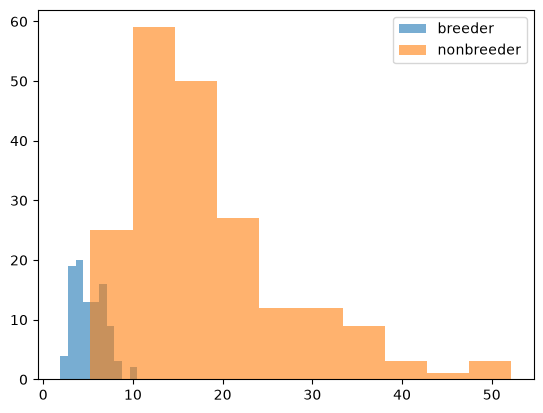

In [12]:
mean_activity = np.mean(activity, axis=1)

# Breeders are always the first 99 rows
plt.hist(mean_activity[:99], alpha=0.6, label='breeder')
plt.hist(mean_activity[99:], alpha=0.6, label='nonbreeder')
plt.legend()
plt.show()

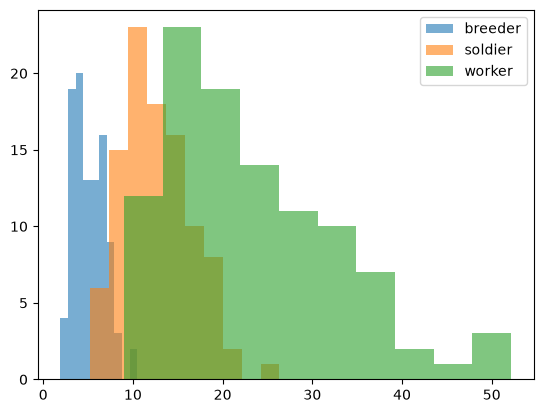

In [13]:
# Boolean indexing: select rows where the label matches
plt.hist(mean_activity[labels[:, 1] == 'breeder'], alpha=0.6, label='breeder')
plt.hist(mean_activity[labels[:, 1] == 'soldier'], alpha=0.6, label='soldier')
plt.hist(mean_activity[labels[:, 1] == 'worker'],  alpha=0.6, label='worker')
plt.legend()
plt.show()

## 3. Train/test split

---
**INSTRUCTOR NOTES**

This is the core ML protocol moment. Spend time here.

Key point: we hold back 20% of the data now and do not touch it until after training. If the model works on data it has never seen, it has learned something real — not just memorised the training examples.

`stratify` just ensures each group is equally represented in both sets — worth mentioning but don't dwell on it.

---

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    activity, labels, test_size=0.2, random_state=42, stratify=labels[:, 1]
)

print('Training animals:', len(X_train))
print('Test animals:', len(X_test))

Training animals: 240
Test animals: 60


## 4. Model 1 — Breeder vs non-breeder

---
**INSTRUCTOR NOTES**

Simple question first: can the model tell breeders from everyone else?

`LogisticRegression` is the model. Students don't need to understand it mathematically — it finds a boundary that separates the groups. `.fit()` is training. `.predict()` is applying it to new data.

Training and test accuracy should be similar (~95%). The model generalises.

---

In [15]:
y_train_binary = y_train[:, 0]
y_test_binary  = y_test[:,  0]

model_binary = LogisticRegression(max_iter=1000)
model_binary.fit(X_train, y_train_binary)

print('Training accuracy:', accuracy_score(y_train_binary, model_binary.predict(X_train)))
print('Test accuracy:    ', accuracy_score(y_test_binary,  model_binary.predict(X_test)))

Training accuracy: 0.9916666666666667
Test accuracy:     0.9333333333333333


## 5. Model 2 — Breeder vs soldier vs worker

---
**INSTRUCTOR NOTES**

Harder question: three groups instead of two, and soldiers and workers overlap.

Accuracy will be lower (~80%). Ask students: where do they think the errors are? Then show the confusion matrix — errors should be concentrated at the soldier/worker boundary.

Key message: harder problems produce more errors. This connects directly to LLMs — language is a much harder problem than activity counts, which is why you need billions of training examples.

**These results are what students bring to the LLM exercise later.**

---

In [20]:
y_train_multi = y_train[:, 1]
y_test_multi  = y_test[:,  1]

model_multi = LogisticRegression(max_iter=10000)
model_multi.fit(X_train, y_train_multi)

print('Training accuracy:', accuracy_score(y_train_multi, model_multi.predict(X_train)))
print('Test accuracy:    ', accuracy_score(y_test_multi,  model_multi.predict(X_test)))

Training accuracy: 0.9083333333333333
Test accuracy:     0.75


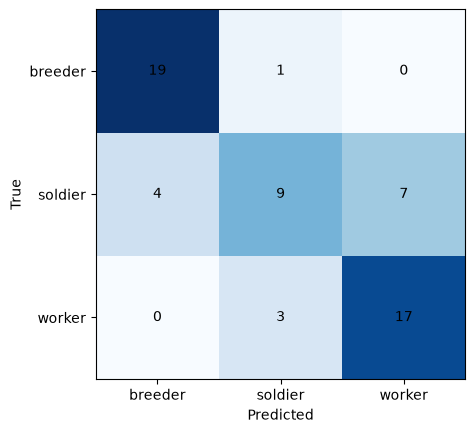

In [21]:
# Confusion matrix: rows = true label, columns = predicted label
classes = ['breeder', 'soldier', 'worker']
cm = confusion_matrix(y_test_multi, model_multi.predict(X_test), labels=classes)

plt.imshow(cm, cmap='Blues')
plt.xticks(range(3), classes)
plt.yticks(range(3), classes)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

---
## INSTRUCTOR ONLY — visualisation demo

Do not ask students to run these cells. Show them yourself to illustrate the difference between the two models.

---

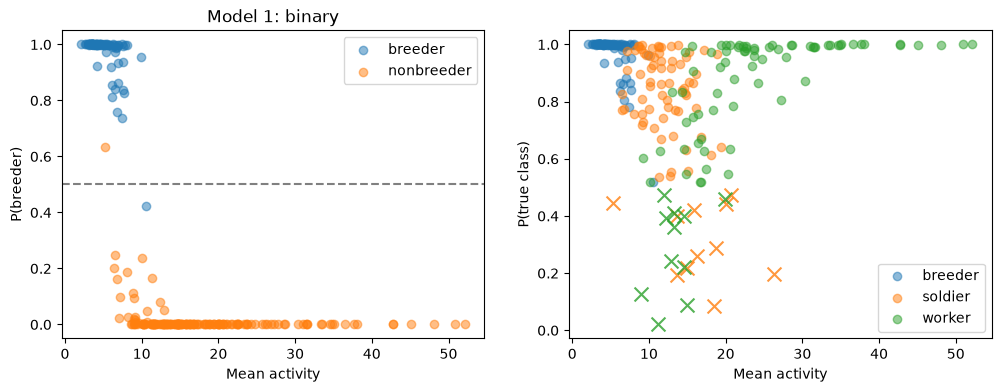

In [26]:
mean_train = X_train.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Binary model
is_breeder = y_train_binary == 'breeder'
axes[0].scatter(mean_train[is_breeder],  model_binary.predict_proba(X_train)[is_breeder,  0], alpha=0.5, label='breeder')
axes[0].scatter(mean_train[~is_breeder], model_binary.predict_proba(X_train)[~is_breeder, 0], alpha=0.5, label='nonbreeder')
axes[0].axhline(0.5, color='grey', linestyle='--')
axes[0].set_xlabel('Mean activity')
axes[0].set_ylabel('P(breeder)')
axes[0].set_title('Model 1: binary')
axes[0].legend()

# Multiclass model
probas = model_multi.predict_proba(X_train)
correct = model_multi.predict(X_train) == y_train_multi

# probability of the true class for each animal
mean_train = X_train.mean(axis=1)
probas = model_multi.predict_proba(X_train)
correct = model_multi.predict(X_train) == y_train_multi
true_class_idx = [list(model_multi.classes_).index(r) for r in y_train_multi]
true_proba = probas[np.arange(len(probas)), true_class_idx]

colours = {'breeder': 'C0', 'soldier': 'C1', 'worker': 'C2'}

for role in model_multi.classes_:
    mask = y_train_multi == role
    c = colours[role]
    plt.scatter(mean_train[mask & correct],  true_proba[mask & correct],  marker='o', alpha=0.5, label=role, color=c)
    plt.scatter(mean_train[mask & ~correct], true_proba[mask & ~correct], marker='x', alpha=0.8, s=100, color=c)

plt.xlabel('Mean activity')
plt.ylabel('P(true class)')
plt.legend()
plt.show()

## 6. From numbers to language

---
**INSTRUCTOR NOTES**

Talk through this slide before moving to the LLM discussion. No code.

---

What we just did:

- Split data into training and test sets
- Fitted a model on the training data
- Tested it on data it had never seen
- Harder problems (more classes, more overlap) produced more errors

A large language model does exactly the same thing, but the input is words and the task is predicting the next word in a sentence. Instead of 300 animals, it trains on billions of documents. The logic is identical. The scale is not.